In [266]:
import talib
import scipy.stats
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.subplots as sub
import quantstats as qs
from jup.helpers.charts import (
    get_layout,
    get_price_trace,
    add_trade_markers,
    remove_x_gaps,
    detect_range_rule,
)
from jup.helpers.data_sources import get_exante_data, resample_ohlc

pd.options.display.width = 150

# ticker = "EUR:CHF"
# ticker = "AUD:NZD"
# ticker = "GBP:CHF"
ticker = "USD:CAD"  # 117T

src = get_exante_data(ticker, start="2021-01-01 00:00+0", end="2021-03-01 00:00+0")
src = resample_ohlc(src, "3h")
_, range_rule = detect_range_rule(src)

print(f"{ticker}, {len(src)} × {range_rule}")
print(f"From: {src.index[0]:%Y-%m-%d %H:%M}")
print(f"To:   {src.index[-1]:%Y-%m-%d %H:%M}")

USD:CAD, 330 × 3h
From: 2021-01-03 21:00
To:   2021-03-01 00:00
USD:CAD, 330 × 3h
From: 2021-01-03 21:00
To:   2021-03-01 00:00


Stop Range: 0.005
Range Width: 1.5
Ind Shift: 134
Kama Limit: 1.5
Ema Period: 24
Atr Period: 5
Stdev Period: 20
Adx Period: 14
Price Change Limit 0: 1
Price Change Limit 1: 3
Price Change Limit 2: 5

Profit: -66.65
Total: -47.65
Gross: +294.30  -341.95
Fee: -19.00  39.87%
Buy:   8   Sell: 11   Stop: 4
Profit Factor: 0.86
R^2: 0.052
Norm Std Err: 12.46



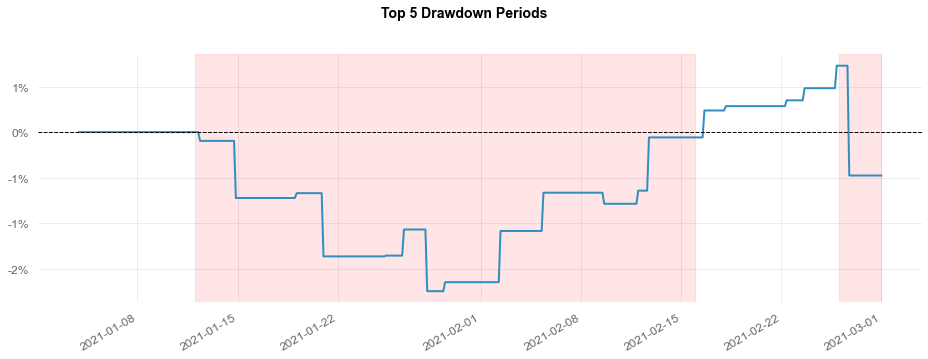

In [267]:
md = src.copy(deep=True)

o = {
    "stop_range": 0.005,
    "range_width": 1.5,
    "ind_shift": 24 + 110,
    "kama_limit": 1.5,
    "ema_period": 24,
    # "ema1_period": 24,
    # "ema2_period": 20,
    "atr_period": 5,
    "stdev_period": 20,
    "adx_period": 14,
    "price_change_limit_0": 1,
    "price_change_limit_1": 3,
    "price_change_limit_2": 5,
}

for k, v in o.items():
    print(f"{k.replace('_', ' ').title()}: {v}")

trading_position = 10_000
leverage = 1
initial_deposit = trading_position // leverage


########################################
#
# md["ema1"] = talib.MA(md["close"], timeperiod=o["ema1_period"], matype=2)
# md["ema2"] = talib.MA(md["close"], timeperiod=o["ema2_period"], matype=0)

# md["mid"] = (md["ema1"] + md["ema2"]) / 2
md["mid"] = talib.EMA(md["close"], timeperiod=o["ema_period"])

price_channel = talib.ATR(md["high"], md["low"], md["close"], timeperiod=o["atr_period"])
md["stdev"] = talib.STDDEV(md["close"], timeperiod=o["stdev_period"], nbdev=1)

# price_channel = md["atr"]
# price_channel = md[["atr", "stdev"]].max(axis=1)
# price_channel = (md["atr"] + md["stdev"]) / 2

md["sar"] = talib.SAR(md["high"], md["low"], acceleration=0.01, maximum=0.2)
md["kama"] = talib.KAMA(md["close"])
md["kama_diff"] = abs(md.kama - md.kama.shift(1)) / md.kama * 10000

# # win = o["kama_change_sum_window"]
# # change = pd.DataFrame().assign(change=(md.mid - md.mid.shift(1)) / md.mid)
# md["price_change_0"] = (md.close - md.close.shift(5)) / md.close * 1000
# md["price_change_1"] = (md.close - md.close.shift(10)) / md.close * 1000
# md["price_change_2"] = (md.close - md.close.shift(20)) / md.close * 1000
#
# md["price_change_0"] = talib.MA(md["price_change_0"], timeperiod=2, matype=4)
# md["price_change_1"] = talib.MA(md["price_change_1"], timeperiod=2, matype=4)
# md["price_change_2"] = talib.MA(md["price_change_2"], timeperiod=2, matype=4)

md["top"] = md["mid"] + o["range_width"] * price_channel
md["bottom"] = md["mid"] - o["range_width"] * price_channel

# Нижний индикатор
ind = o["ind_shift"] - talib.ADX(
    md["high"], md["low"], md["close"], timeperiod=o["adx_period"]
)
md["ind"] = talib.MA(ind, timeperiod=2, matype=1)

########################################

# Пустые значения в колонках
md["position"] = 0
md["price"] = None
md["price_close"] = None
md["deposit"] = initial_deposit

bar = list(md.head(1).itertuples())[0]
for cur in md.itertuples():

    dt = cur.Index

    # Currentley open position
    if md.loc[bar.Index].price_close:
        position = 0
        position_price = None
    else:
        position = md.loc[bar.Index].position
        position_price = md.loc[bar.Index].price

    signal = None

    ####################
    # OPEN
    if not signal:
        if bar.kama_diff < o["kama_limit"] and bar.ind > 0:
            if not position and bar.low < bar.bottom:
                signal = "enter_long:buy"

            if not position and bar.high > bar.top:
                signal = "enter_short:sell"

    ####################
    # CLOSE
    if not signal and position < 0 and bar.low < bar.mid:
        signal = "exit_short:buy"

    if not signal and position > 0 and bar.high > bar.mid:
        signal = "exit_long:sell"

    ####################
    # STOP
    if position_price:
        if not signal and position < 0:
            stop_line = position_price + o["stop_range"]
            if bar.low >= stop_line:
                signal = "stop_short:buy"

        if not signal and position > 0:
            stop_line = position_price - o["stop_range"]
            if bar.high <= stop_line:
                signal = "stop_long:sell"

    # Signal structure: "{action}_{position_direction}:{trade_direction}"
    if signal:
        if "stop" in signal or "exit" in signal:
            md.at[dt, "position"] = position
            md.at[dt, "price"] = position_price
            md.at[dt, "price_close"] = cur.open
        else:
            md.at[dt, "position"] = 1 if "long" in signal else -1
            md.at[dt, "price"] = cur.open

        md.at[dt, "action"] = signal.split(":")[0]
        md.at[dt, "side"] = signal.split(":")[1]

    else:
        # сохраняется предыдущая позиция
        md.at[dt, "position"] = position
        md.at[dt, "price"] = position_price if position else None

    bar = cur

tp = trading_position
md.loc[md["action"] == "exit_short", "profit"] = (md["price"] - md["price_close"]) * tp
md.loc[md["action"] == "exit_long", "profit"] = -(md["price"] - md["price_close"]) * tp
md.loc[md["action"] == "stop_short", "profit"] = (md["price"] - md["price_close"]) * tp
md.loc[md["action"] == "stop_long", "profit"] = -(md["price"] - md["price_close"]) * tp
md["profit"].fillna(0, inplace=True)

md["deposit"] = initial_deposit + md["profit"].cumsum()

# trades = md[md["action"] == "stop_short"]
# print(trades[["position", "price", "price_close", "deposit", "action", "side", "profit"]])

########################################


total_up = md.loc[md["profit"] > 0].profit.sum()
total_down = md.loc[md["profit"] < 0].profit.sum()

open_buy = len(md.loc[md["action"] == "enter_long"])
open_sell = len(md.loc[md["action"] == "enter_short"])
stop_cnt = len(md.loc[md["action"] == "stop_long"])
stop_cnt += len(md.loc[md["action"] == "stop_short"])

total_profit = md.profit.sum()


stock = pd.Series(md["deposit"])

pf = abs(total_up / (total_down or 0.01))
fee = -(open_buy + open_sell) * (0.005 / 100) * 2 * trading_position
profit_after_fee = total_profit + fee
fee_rel = abs(fee / total_profit) * 100

# R2
x = pd.Series(np.arange(len(stock)))
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, stock)
r2 = r_value**2
norm_std_err = std_err * len(stock)


print()
# print(f"Deposit: {deposit:0.2f}")
print(f"Profit: {profit_after_fee:+0.2f}")
print(f"Total: {total_profit:+0.2f}")
print(f"Gross: {total_up:+0.2f}  {total_down:+0.2f}")
print(f"Fee: {fee:+0.2f}  {fee_rel:0.2f}%")
print(f"Buy:   {open_buy}   Sell: {open_sell}   Stop: {stop_cnt}")
print(f"Profit Factor: {pf:0.2f}")
print(f"R²: {r2:0.3f}")
print(f"Norm Std Err: {norm_std_err:0.2f}")
# print(f"Mean profit: {mean(profits):0.2f}")
print()


# import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = [15, 3]
# ax = pd.Series(profits).plot.hist(bins=50, width=3)
# [r.set_color('#dd0000') for r in ax.patches if r.get_x() < 0]


 #%%

# # benchmark
# res = {}
# for line in open("../front/data_big/stats.csv", "r"):
#     if "Value" not in line:
#         stats = line.strip().split(",")
#         dt = datetime.strptime(stats[0], "%Y-%m-%d %H:%M:%S")
#         res[dt] = float(stats[1])
# benchmark = pd.DataFrame(pd.Series(res))
# benchmark.index.tz_localize("UTC")
#
# # хуй знает, зачем это, но при нескольких значениях
# # на интервал оно может не работать иначе
# benchmark = benchmark.resample("1h").mean().dropna()


qs.plots.drawdowns_periods(stock, ylabel=False, lw=2, subtitle=False, figsize=(13, 5))
# qs.plots.returns(stock, ylabel=False, lw=2, subtitle=False, figsize=(13, 5))
# qs.reports.metrics(stock, mode="full", compounded=True)
# qs.reports.plots(stock, stock1, mode="full", figsize=(10, 5), compounded=True)
# qs.reports.html(stock, benchmark, output="res.html", compounded=True)


In [268]:
df = md.tail(500)

ohlc = get_price_trace(df)
layout = get_layout()

fig = sub.make_subplots(
    figure=go.Figure(layout=layout),
    rows=5,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    row_heights=[0.6, 0.1, 0.1, 0.1, 0.1],
)
# Правильный rangeslider
# fig.add_trace(go.Scatter(x=df.index, y=df["mid"]), row=3, col=1)
# fig.update_layout(xaxis3=dict(rangeslider=dict(visible=True, thickness=0.05)))
# fig['layout']['xaxis2']['visible'] = False
# fig['layout']['yaxis3']['visible'] = False

# Основной график, цена
fig.add_trace(ohlc, 1, 1)

# Маркеры торгов
add_trade_markers(fig, df)

# Индикаторы на графике
line = dict(color="rgba(0,0,0,0.2)", width=1)
line_or = dict(color="#f50", width=1)
fig.add_trace(go.Scatter(x=df.index, y=df["top"], line=line, name="top"))
fig.add_trace(go.Scatter(x=df.index, y=df["mid"], line=line, name="mid"))
fig.add_trace(go.Scatter(x=df.index, y=df["bottom"], line=line, name="btm"))

# fig.add_trace(go.Scatter(x=df.index, y=df["sar"], mode="markers", marker=dict(size=3)))
# fig.add_trace(go.Scatter(x=df.index, y=df["kama"], mode="lines"))
# fig.add_trace(go.Scatter(x=df.index, y=df["ema2"], mode="markers"))

# Индикаторы отдельные
# color = np.where((df["rsi"] < 42) | (df["rsi"] > 58), 'red', '#0b0')
# fig.add_trace(go.Bar(x=df.index, y=df["rsi"], marker_color=color), row=2, col=1)

color = np.where((df["kama_diff"] < 0), 'red', '#0b0')
fig.add_trace(go.Bar(x=df.index, y=df["kama_diff"], marker_color=color), row=2, col=1)

# fig.add_trace(go.Scatter(x=df.index, y=df["price_change_0"]), row=3, col=1)
# fig.add_trace(go.Scatter(x=df.index, y=df["price_change_1"]), row=4, col=1)
# fig.add_trace(go.Scatter(x=df.index, y=df["price_change_2"]), row=5, col=1)

remove_x_gaps(fig, md, df, skip_start=20, skip_end=0)
fig.show(config={"displayModeBar": False, "showTips": False})